In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")

print("Path to dataset files:", path)

100%|██████████| 5.21k/5.21k [00:00<00:00, 9.94MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rohan0301/unsupervised-learning-on-country-data/versions/2


In [3]:
import pandas as pd

df = pd.read_csv(path+"/Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [6]:
X = df.drop("country", axis=1)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.decomposition import PCA

In [12]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [13]:
print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", pca.explained_variance_ratio_.sum())

Original shape: (167, 9)
Reduced shape: (167, 6)
Explained Variance Ratio: [0.4595174  0.17181626 0.13004259 0.11053162 0.07340211 0.02484235]
Total Variance Explained: 0.9701523224082289


#Kmeans

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
sil_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))


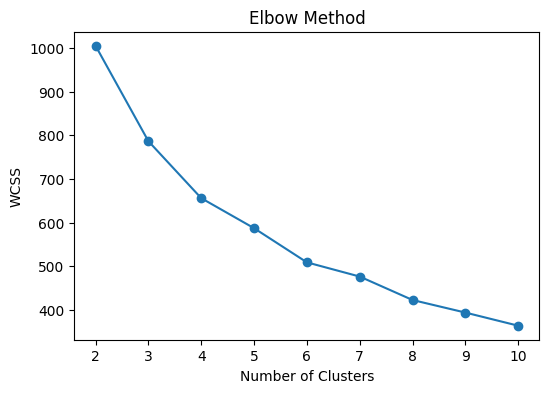

In [17]:
plt.figure(figsize=(6,4))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

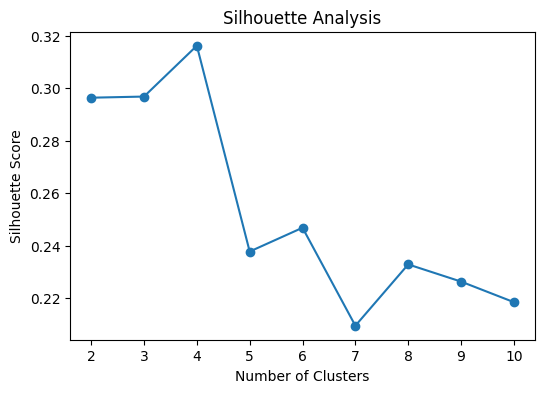

In [18]:
plt.figure(figsize=(6,4))
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()


In [19]:
k=4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_pca)

In [30]:
print("Silhouette Score:", silhouette_score(X_pca, df["Cluster"]))

Silhouette Score: 0.3161600478918799


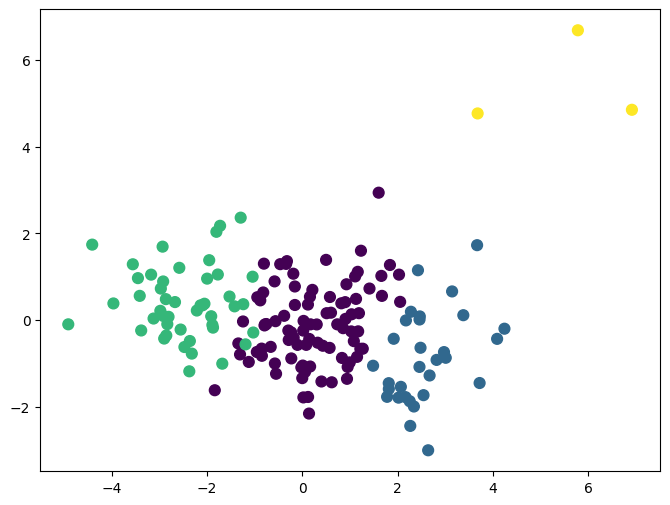

In [20]:
pca_vis = PCA(n_components=2, random_state=42)
X_vis = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=df["Cluster"],
    cmap="viridis",
    s=60
)

In [21]:
print(df.groupby("Cluster").mean(numeric_only=True))

print("\nCountries in each cluster:")
for i in sorted(df["Cluster"].unique()):
    print(f"\nCluster {i}")
    print(df[df["Cluster"] == i]["country"].tolist())

         child_mort     exports    health     imports        income  \
Cluster                                                               
0         21.743182   41.316920  6.259318   48.075749  12972.386364   
1          4.953333   45.826667  9.168667   39.736667  45250.000000   
2         93.841304   28.837174  6.346957   42.128261   3738.978261   
3          4.133333  176.000000  6.793333  156.666667  64033.333333   

         inflation  life_expec  total_fer          gdpp  
Cluster                                                  
0         7.430580   72.755682   2.293295   6912.636364  
1         2.742200   80.376667   1.795333  43333.333333  
2        12.087065   59.232609   5.054348   1826.130435  
3         2.468000   81.433333   1.380000  57566.666667  

Countries in each cluster:

Cluster 0
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and 

In [22]:
# Cluster 2: Least developed countries.
# Cluster 0: Developing or emerging economies.
# Cluster 1: Developed countries.
# Cluster 3: Highly developed, globally integrated economies with exceptionally high trade intensity.

#Agglomerative

In [23]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

agg = AgglomerativeClustering(n_clusters=4)

labels = agg.fit_predict(X_pca)

df["Agglomerative_Cluster"] = labels

print("Silhouette Score:", silhouette_score(X_pca, labels))

print(df.groupby("Agglomerative_Cluster").mean(numeric_only=True))

Silhouette Score: 0.299641043902051
                       child_mort     exports    health     imports  \
Agglomerative_Cluster                                                 
0                       86.741509   28.926774  6.439811   43.101243   
1                        6.056667   46.393333  8.789667   38.060000   
2                       19.749383   42.126914  6.331358   48.574074   
3                        4.133333  176.000000  6.793333  156.666667   

                             income  inflation  life_expec  total_fer  \
Agglomerative_Cluster                                                   
0                       4159.490566  12.833491   60.130189   4.794528   
1                      46160.000000   4.169433   79.970000   1.930333   
2                      13158.148148   6.011160   73.487654   2.174691   
3                      64033.333333   2.468000   81.433333   1.380000   

                               gdpp   Cluster  
Agglomerative_Cluster                          
0 

In [27]:
agg_summary = df.groupby("Agglomerative_Cluster").mean(numeric_only=True)
print("\nAgglomerative Cluster Summary:")
print(agg_summary)

# Countries in each cluster
print("\nCountries in each cluster:")
for i in sorted(df["Agglomerative_Cluster"].unique()):
    print(f"\nCluster {i}")
    print(df[df["Agglomerative_Cluster"] == i]["country"].tolist())


Agglomerative Cluster Summary:
                       child_mort     exports    health     imports  \
Agglomerative_Cluster                                                 
0                       86.741509   28.926774  6.439811   43.101243   
1                        6.056667   46.393333  8.789667   38.060000   
2                       19.749383   42.126914  6.331358   48.574074   
3                        4.133333  176.000000  6.793333  156.666667   

                             income  inflation  life_expec  total_fer  \
Agglomerative_Cluster                                                   
0                       4159.490566  12.833491   60.130189   4.794528   
1                      46160.000000   4.169433   79.970000   1.930333   
2                      13158.148148   6.011160   73.487654   2.174691   
3                      64033.333333   2.468000   81.433333   1.380000   

                               gdpp   Cluster  DBSCAN_Cluster  
Agglomerative_Cluster                 

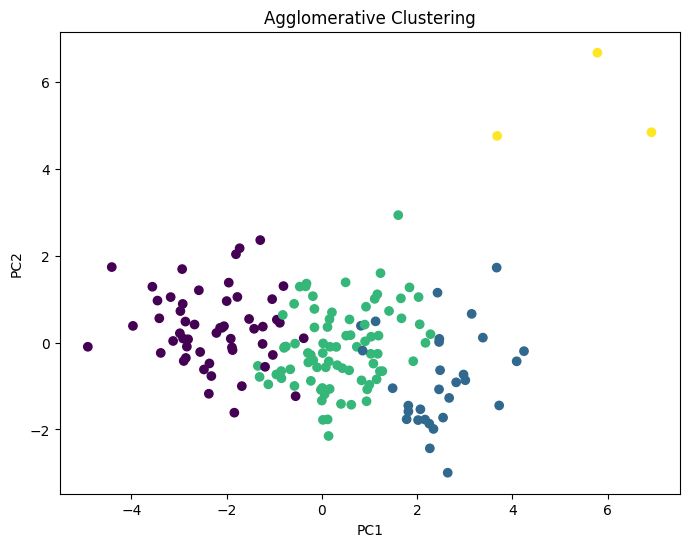

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(X_vis[:,0], X_vis[:,1], c=labels, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agglomerative Clustering")
plt.show()

#DBscan

In [25]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1.2, min_samples=5)

labels = db.fit_predict(X_pca)

df["DBSCAN_Cluster"] = labels

print("Clusters:", set(labels))

Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}


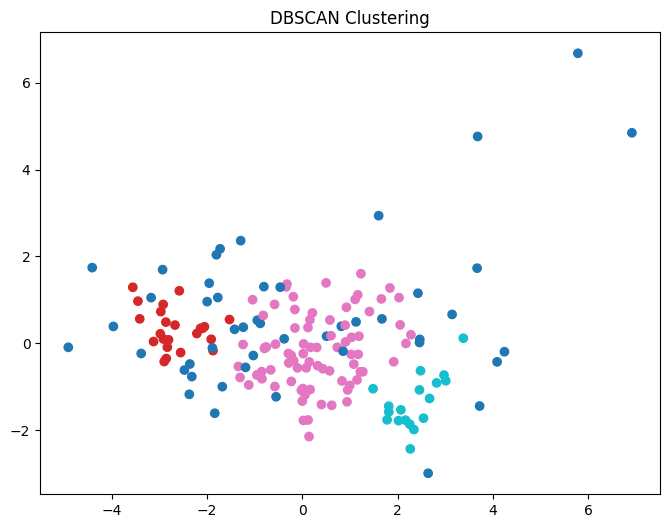

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(X_vis[:,0], X_vis[:,1], c=labels, cmap='tab10')
plt.title("DBSCAN Clustering")
plt.show()

In [29]:
mask = labels != -1  # Exclude noise
print("Silhouette Score:",
      silhouette_score(X_pca[mask], labels[mask]))

# Cluster Summary
dbscan_summary = df.groupby("DBSCAN_Cluster").mean(numeric_only=True)
print("\nDBSCAN Cluster Summary:")
print(dbscan_summary)

# Countries in each cluster
print("\nCountries in each cluster:")
for i in sorted(df["DBSCAN_Cluster"].unique()):
    if i == -1:
        print("\nNoise (-1)")
    else:
        print(f"\nCluster {i}")
    print(df[df["DBSCAN_Cluster"] == i]["country"].tolist())

Silhouette Score: 0.3969168738920193

DBSCAN Cluster Summary:
                child_mort    exports     health    imports        income  \
DBSCAN_Cluster                                                              
-1               53.329787  52.406362   6.740851  53.922679  24401.000000   
 0               95.808696  24.548696   5.883913  39.282609   1877.652174   
 1               20.327848  40.457975   6.367468  47.745570  12671.265823   
 2                4.172222  35.627778  10.168889  34.494444  37338.888889   

                inflation  life_expec  total_fer          gdpp   Cluster  \
DBSCAN_Cluster                                                             
-1              13.176191   67.544681   3.418511  17719.765957  1.319149   
 0               7.365435   58.969565   5.411739    764.826087  2.000000   
 1               6.156000   73.337975   2.213038   7264.481013  0.063291   
 2               1.364222   81.011111   1.796667  41150.000000  1.000000   

                Ag

#Compare

In [32]:
from sklearn.cluster import KMeans, AgglomerativeClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

scores = {}

# KMeans
labels = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_pca)
scores["KMeans"] = silhouette_score(X_pca, labels)

# Agglomerative
labels = AgglomerativeClustering(n_clusters=4).fit_predict(X_pca)
scores["Agglomerative"] = silhouette_score(X_pca, labels)

# DBSCAN
from sklearn.cluster import DBSCAN

db_labels = DBSCAN(eps=1.2, min_samples=5).fit_predict(X_pca)

# Compute silhouette only if there are at least 2 clusters (excluding noise)
mask = db_labels != -1
if len(set(db_labels[mask])) > 1:
    scores["DBSCAN"] = silhouette_score(X_pca[mask], db_labels[mask])

# Print all scores
print("Silhouette Scores:")
for algo, score in scores.items():
    print(f"{algo}: {score:.4f}")

# Highest score
best_algo = max(scores, key=scores.get)
best_score = scores[best_algo]
print("\nBest Clustering Algorithm")
print(f"Algorithm: {best_algo}")
print(f"Highest Silhouette Score: {best_score:.4f}")

Silhouette Scores:
KMeans: 0.3162
Agglomerative: 0.2996
DBSCAN: 0.3969

Best Clustering Algorithm
Algorithm: DBSCAN
Highest Silhouette Score: 0.3969


In [34]:
import joblib

# Dump the trained model
joblib.dump(best_algo, "best_clustering_model.pkl")

# Dump the scaler
joblib.dump(scaler, "scaler.pkl")

# Dump the PCA model
joblib.dump(pca, "pca.pkl")

print("Model, Scaler, and PCA saved successfully.")

Model, Scaler, and PCA saved successfully.
